In [ ]:
!pip install -q google.genai

In [ ]:
from google.colab import userdata
import os
os.environ ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [ ]:
from google import genai
cliente = genai.Client()

In [ ]:
respuesta = cliente.models.generate_content(
    model= 'gemini-2.5-flash',
    contents= ' Cuál es la Ciudad más austral de Argentina?'
)
print (respuesta.text)

La ciudad más austral de Argentina es **Ushuaia**.

Se encuentra en la provincia de Tierra del Fuego, Antártida e Islas del Atlántico Sur, y es conocida como la "Ciudad del Fin del Mundo".


In [ ]:
from google.colab import files
os.makedirs ("PDFs", exist_ok= True)
uploader = files.upload ()
for archivo in uploader.keys():
  os.rename (archivo, f"PDFs/{archivo}")

Saving TechNova Solutions.pdf to TechNova Solutions.pdf


In [ ]:
!pip install -q langchain-community pypdf

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
documentos = []
for archivo2 in os.listdir ("PDFs"):
  if archivo2.endswith('.pdf'): # Filter for actual PDF files
    ruta = os.path.join ("PDFs", archivo2)
    loader = PyPDFLoader (ruta)
    paginas = loader.load()
    documentos.extend (paginas)

In [ ]:
documentos [0]

Document(metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'TechNova Solutions S', 'source': 'PDFs/TechNova Solutions.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='TechNova  Solutions  S.A.  \nInforme\n \nde\n \nRecursos\n \nHumanos\n \n–\n \nAño\n \n2025\n \n(Base\n \nestructurada\n \npara\n \nanálisis\n \ncon\n \nInteligencia\n \nArtificial)\n \n \n📊  Resumen  general  \n●  Cantidad  total  de  empleados:  30  ●  Estructura  organizacional  basada  en  sectores  tecnológicos  y  de  soporte  ●  Datos  anonimizados  mediante  identificadores  únicos  (ID)  \n \n🏢  Distribución  por  sectores  \n●  Engineering:  7  empleados  ●  Data:  5  empleados  ●  AI  Lab:  4  empleados  ●  Product:  4  empleados  ●  Security:  3  empleados  ●  Finance:  3  empleados  ●  HR:  4  empleados  \n \n📈  Desempeño  general  \n●  Alto:  13  empleados  ●  Medio:  10  empleados  ●  Bajo:  7  empleados  \nEl  mayor  porcentaje 

In [ ]:
len (documentos)

3

In [ ]:
!pip install -q langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
divisor = RecursiveCharacterTextSplitter (
    chunk_size= 400,
    chunk_overlap= 40,
    separators= ["\n\n", "\n", ". ", " ", ""]
)
fragmentos = divisor.split_documents (documentos)

In [ ]:
len(fragmentos)

13

In [ ]:
fragmentos[2]

Document(metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'TechNova Solutions S', 'source': 'PDFs/TechNova Solutions.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='El  mayor  porcentaje  de  desempeño  alto  se  concentra  en  los  sectores  Data  y  AI  Lab .  \n \n🧾  Política  de  vacaciones  (según  antigüedad)  \n●  Hasta  5  años:  14  días  ●  Entre  5  y  10  años:  21  días  ●  Más  de  10  años:  28  días  \n \n📉  Análisis  de  vacaciones  2025')

In [ ]:
!pip install -q langchain-google-genai faiss-cpu langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.2 MB/s eta 0:00:00


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

In [ ]:
len (fragmentos)

13

In [ ]:
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:11],
    embedding=embeddings
)

In [ ]:
vectorstore2 = FAISS.from_documents(
    documents=fragmentos[11:13],
    embedding=embeddings
)

In [ ]:
vectorstore1.index.reconstruct (0)

array([-0.01204205,  0.01868876,  0.01528075, ...,  0.02475839,
        0.01368632, -0.02046796], dtype=float32)

In [ ]:
vectorstore1.merge_from (vectorstore2)

In [ ]:
consulta = "cuántos empleados aún no tomaron vacaciones?"
resultados = vectorstore1.similarity_search (
    consulta,
    k= 3
)

for i in resultados:
  print (i)
  print("\n")



page_content='📉  Análisis  de  vacaciones  2025  
●  Empleados  con  vacaciones  pendientes:  16  ●  Empleados  que  no  tomaron  más  del  50%  de  su  licencia:  9' metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'TechNova Solutions S', 'source': 'PDFs/TechNova Solutions.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}


page_content='●  Sectores  con  mayor  acumulación  de  días  pendientes:  ○  Engineering  ○  Data  
 
👥  Base  de  empleados  (estructura  para  análisis)  
Formato  por  registro:  
ID  |  Sector  |  Antigüedad  |  Salario  |  Vacaciones  disponibles  |  Vacaciones  tomadas  |  
Vacaciones
 
restantes
 
|
 
Desempeño
 
 
ID-001  |  Engineering  |  3  años  |  920000  ARS  |  14  |  8  |  6  |  Medio  
ID-002' metadata={'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'TechNova Solutions S', 'source': 'PDFs/TechNova Solutions.pdf', 'total_pages': 3, 'p

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai.chat_models import ChatGoogleGenerativeAIError

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

retriever = vectorstore1.as_retriever(
    search_kwargs={"k": 4}
)

In [ ]:
def preguntar_rag(pregunta):
    """Busca contexto relevante en los documentos y genera una respuesta."""
    # Paso 1: Buscar los chunks más relevantes
    docs = retriever.invoke(pregunta)
    contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)

    # Paso 2: Construir el prompt con el contexto encontrado
    prompt = f"""Eres un asistente experto que responde preguntas basándose ÚNICAMENTE
    en el contexto proporcionado. Si la información no está en el contexto,
    di que no tienes suficiente información.

    Contexto: {contexto}

    Pregunta: {pregunta}

    Respuesta:"""

    # Paso 3: Enviar al modelo y devolver la respuesta
    respuesta = llm.invoke(prompt)
    return respuesta.content


In [ ]:
preguntar_rag ("Cuántos empleados del AI Lab tienen desempeño alto?")

'Según el contexto proporcionado, los empleados del AI Lab con desempeño alto son:\n*   ID-023\n*   ID-030\n\nPor lo tanto, 2 empleados del AI Lab tienen desempeño alto.'

In [ ]:
preguntar_rag ("Qué país ganó las dos últimas copas América 2021 y 2024,  Mundial 2022 y Finalissima 2022?")

'No tengo suficiente información en el contexto proporcionado para responder a esa pregunta.'

In [ ]:
!pip install -q langgraph google-search-results markdown fpdf2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 9.3 MB/s eta 0:00:00


In [ ]:
os.environ ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [ ]:
from langchain_community.utilities import SerpAPIWrapper
buscador = SerpAPIWrapper ()
buscador.run ("cuántos atletas argentinos van a las olimpiadas de invierno en Milán 2026?")


"['Argentina compitió con ocho atletas en Milano Cortina 2026, su mayor delegación en los últimos veinte años para unos Juegos Olímpicos de Invierno. Los atletas ...', 'Serán ocho los representantes nacionales, el mayor número desde la última cita en suelo italiano hace 20 años en Turín 2006, donde fueron nueve ...', 'Compiten en total 2.900 atletas de todo el mundo. El evento se realiza en Milán, Cortina d´Ampezzo y otras sedes. Hay 114 medallas en disputa en ...', 'La cita más importante del deporte invernal, que se disputará entre el 6 y el 22 de febrero, contará con la participación de ocho argentinos ...', 'Pasión en la nieve: quiénes son los ocho argentinos que participarán en los Juegos Olímpicos de Invierno Milano Cortina 2026 ...', 'En esta disciplina, la delegación argentina estará integrada por Francesca Baruzzi, Nicole Begué y Tiziano Gravier. Baruzzi, de 27 años y oriunda de San Carlos ...', 'La delegación argentina está lista para su participación en los Juegos Olímpicos 

Construir el grafo con LangGraph

                    ┌─── "rag" ───→ [Buscar en documentos] ───┐
[START] → [Agente]                                         → [Generar Markdown] → END
                    └─── "web" ───→ [Buscar en la web] ───────┘


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str


In [ ]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa TechNova Solutions S.A.
 o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}



In [ ]:
def nodo_rag(state: AgentState):
  contexto = preguntar_rag(state["pregunta"])
  return {"contexto": contexto}


In [ ]:
def nodo_web(state: AgentState):
  contexto = buscador.run(state["pregunta"])
  return {"contexto": contexto}


In [ ]:
def nodo_markdown(state: AgentState):
  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)
  return {"respuesta": respuesta.content}


In [ ]:
def decidir_fuente(state: AgentState):
  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"


In [ ]:
grafo = StateGraph (AgentState)
grafo.add_node ("Agente", nodo_agente)
grafo.add_node ("RAG", nodo_rag)
grafo.add_node ("Web", nodo_web)
grafo.add_node ("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [ ]:
agente = grafo.compile()

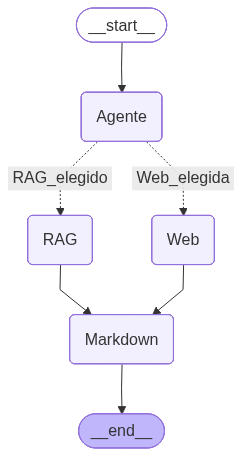

In [ ]:
from IPython.display import Image, display

imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))


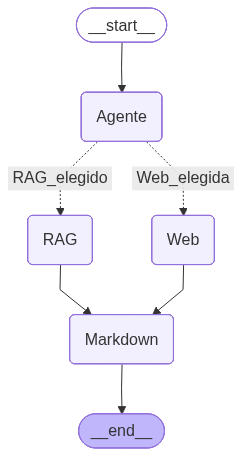

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa TechNova Solutions S.A.
 o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

def nodo_rag(state: AgentState):
  contexto = preguntar_rag(state["pregunta"])
  return {"contexto": contexto}

def nodo_web(state: AgentState):
  contexto = buscador.run(state["pregunta"])
  return {"contexto": contexto}

def nodo_markdown(state: AgentState):
  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)
  return {"respuesta": respuesta.content}

def decidir_fuente(state: AgentState):
  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

grafo = StateGraph (AgentState)
grafo.add_node ("Agente", nodo_agente)
grafo.add_node ("RAG", nodo_rag)
grafo.add_node ("Web", nodo_web)
grafo.add_node ("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

agente = grafo.compile()

from IPython.display import Image, display

imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))

import datetime
from fpdf import FPDF
from google.colab import files
import markdown
from bs4 import BeautifulSoup

# Helper function to sanitize filenames (from previous steps, if not present)
def sanitize_filename(filename):
    """Sanitizes a string to be used as a filename."""
    # Replace invalid characters with underscores
    sanitized = "".join(c if c.isalnum() or c in (' ', '.', '_', '-') else '_' for c in filename)
    # Truncate to a reasonable length to avoid OS limits
    return sanitized[:50].strip()

def ejecutar_agente(pregunta):
  try:
    resultado = agente.invoke({
        "pregunta": pregunta,
        "fuente": "",
        "contexto": "",
        "respuesta": ""
    })

    # Extract information for the PDF report
    pregunta_original = resultado["pregunta"]
    fuente_utilizada = resultado["fuente"]
    contexto_utilizado = resultado["contexto"]
    respuesta_final = resultado["respuesta"] # This is in Markdown

    print("=" * 60)
    print(f"Fuente utilizada: {fuente_utilizada}")
    print("=" * 60)
    print(f"Contexto utilizado: {contexto_utilizado}")
    print("=" * 60)
    print(f"Respuesta final (Markdown): {respuesta_final}") # Log Markdown response

    # Generate unique filename for the PDF
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    sanitized_q = sanitize_filename(pregunta_original)
    filename = f"Informe_{sanitized_q}_{timestamp}.pdf"

    # Create PDF report
    pdf = FPDF()
    pdf.add_page()
    # Using Helvetica as a default font
    pdf.set_font("Helvetica", size=12)

    # Add the original question prominently
    pdf.set_font("Helvetica", 'B', size=12) # Make header bold
    pdf.multi_cell(0, 8, "PREGUNTA REALIZADA:".encode('latin-1', 'replace').decode('latin-1'), border=0, align='L')
    pdf.set_font("Helvetica", size=10) # Content remains regular
    pdf.multi_cell(0, 7, pregunta_original.encode('latin-1', 'replace').decode('latin-1'), border=0, align='L')
    pdf.ln(5)

    # Add source information (unchanged font style)
    pdf.set_font("Helvetica", size=12)
    pdf.multi_cell(0, 8, f"FUENTE UTILIZADA: {fuente_utilizada}".encode('latin-1', 'replace').decode('latin-1'), border=0, align='L')
    pdf.ln(5)

    # Convert Markdown to plain text for PDF output
    # First, convert Markdown to HTML
    html = markdown.markdown(respuesta_final)
    # Then, strip HTML tags to get plain text
    soup = BeautifulSoup(html, 'html.parser')
    plain_text_response = soup.get_text()

    # Add the agent's answer (now plain text)
    pdf.set_font("Helvetica", 'B', size=12) # Make header bold
    pdf.multi_cell(0, 8, "RESPUESTA DEL AGENTE:".encode('latin-1', 'replace').decode('latin-1'), border=0, align='L')
    pdf.set_font("Helvetica", size=10) # Content remains regular
    # The plain_text_response might still have extra newlines or spaces, clean it up
    clean_plain_text_response = "\n".join([line.strip() for line in plain_text_response.splitlines() if line.strip()])
    pdf.multi_cell(0, 7, clean_plain_text_response.encode('latin-1', 'replace').decode('latin-1'), border=0, align='L')
    pdf.ln(5)

    # Add a snippet of the context used (unchanged font style)
    pdf.set_font("Helvetica", size=12)
    pdf.multi_cell(0, 8, "FRAGMENTO DEL CONTEXTO UTILIZADO:".encode('latin-1', 'replace').decode('latin-1'), border=0, align='L')
    pdf.set_font("Helvetica", size=8) # Smaller font for context snippet
    context_snippet = contexto_utilizado[:500] + "..." if len(contexto_utilizado) > 500 else contexto_utilizado
    pdf.multi_cell(0, 6, context_snippet.encode('latin-1', 'replace').decode('latin-1'), border=0, align='L')
    pdf.ln(5)

    # Save and download the PDF
    pdf.output(filename)
    print(f"Reporte PDF generado: {filename}")
    files.download(filename)

    return respuesta_final
  except ChatGoogleGenerativeAIError as e:
    print(f"Error: El agente no pudo generar una respuesta debido a un problema con la API de Gemini: {e}")
    print("Por favor, revisa tu cuota de uso de la API o intenta de nuevo más tarde.")
    return f"Error: No se pudo procesar la pregunta debido a problemas con la API: {e}"

In [ ]:
ejecutar_agente("Mostrame empleados con desempeño alto que no tomaron todas sus vacaciones en 2025.")

El agente decidió la fuente RAG.
Fuente utilizada: RAG
Contexto utilizado: Basándome en el contexto proporcionado, el empleado con desempeño alto que no tomó todas sus vacaciones es:

*   **ID-016** | Engineering | 7 años | 1400000 ARS | 21 (disponibles) | 11 (tomadas) | 10 (restantes) | Alto
Respuesta final: # Empleados con Desempeño Alto que No Tomaron Todas sus Vacaciones

A continuación, se presenta el empleado con desempeño alto que no ha tomado todas sus vacaciones, según el contexto proporcionado:

## Detalles del Empleado

*   **ID del Empleado:** ID-016
*   **Departamento:** Engineering
*   **Antigüedad:** 7 años
*   **Salario Anual:** 1.400.000 ARS
*   **Vacaciones Disponibles:** 21 días
*   **Vacaciones Tomadas:** 11 días
*   **Vacaciones Restantes:** 10 días
*   **Nivel de Desempeño:** Alto

Este empleado cumple con los criterios de tener un desempeño alto y no haber utilizado la totalidad de sus días de vacaciones disponibles.


'# Empleados con Desempeño Alto que No Tomaron Todas sus Vacaciones\n\nA continuación, se presenta el empleado con desempeño alto que no ha tomado todas sus vacaciones, según el contexto proporcionado:\n\n## Detalles del Empleado\n\n*   **ID del Empleado:** ID-016\n*   **Departamento:** Engineering\n*   **Antigüedad:** 7 años\n*   **Salario Anual:** 1.400.000 ARS\n*   **Vacaciones Disponibles:** 21 días\n*   **Vacaciones Tomadas:** 11 días\n*   **Vacaciones Restantes:** 10 días\n*   **Nivel de Desempeño:** Alto\n\nEste empleado cumple con los criterios de tener un desempeño alto y no haber utilizado la totalidad de sus días de vacaciones disponibles.'

In [ ]:
ejecutar_agente ("Qué país ganó las últimas dos Copas América, Mundial 2022 y Finalissima 2022?")

El agente decidió la fuente Web.
Fuente utilizada: Web
Contexto utilizado: ['1. Bandera de Italia · Italia, Campeón de la Eurocopa (2020) (2.° título) ; 2. Bandera de Argentina · Argentina, Campeón de la Copa América. (2021) (15.° título).', 'Tras haber salido campeón de la 47.ª edición de estos juegos que se desarrollaron en Brasil. Concretamente, Argentina ganó la final contra ...', 'Argentina se ha adueñado de este torneo a lo largo de los años y la breve lista de capitanes que han levantado el emblemático trofeo es ...', 'La Finalissima como tal tiene hasta ahora una sola edición y Argentina es la única selección que lo ha ganado. Pero en el palmarés de esta ...', 'Argentina consiguió hacerse con la Finalissima tras derrotar a Italia por 3-0 en 2022, antes de convertirse también en campeones del Mundial que ...', 'Argentina se alza con su decimoquinta Copa América tras ganar a Brasil.', 'Selecciones campeonas de dos o más torneos en la misma temporada Argentina: Mundial y Finalissi

'# El País Campeón de Múltiples Torneos Recientes\n\nBasándonos en el contexto proporcionado, el país que ha logrado ganar las últimas dos Copas América, el Mundial 2022 y la Finalissima 2022 es **Argentina**.\n\n## Logros de Argentina en el Fútbol Internacional\n\nLa selección argentina ha demostrado un dominio notable en el fútbol internacional reciente, acumulando varios títulos importantes:\n\n*   **Copa América:**\n    *   **Copa América 2021:** Argentina se coronó campeona de la 47.ª edición de este torneo, derrotando a Brasil en la final y alzándose con su **decimoquinto título** de Copa América.\n    *   **Copa América 2024:** El contexto también indica que Argentina ganó la edición de 2024 en Estados Unidos, superando a Colombia.\n*   **Mundial 2022:**\n    *   Argentina se convirtió en campeona del Mundial de 2022, un logro que se menciona tras su victoria en la Finalissima de ese mismo año.\n*   **Finalissima 2022:**\n    *   Argentina consiguió hacerse con la Finalissima tr

In [ ]:
from fpdf import FPDF
from google.colab import files

# La última respuesta en Markdown generada por el agente
last_markdown_response = '''# Empleados con Desempeño Alto y Vacaciones Pendientes en 2025

A continuación, se presenta la lista de empleados con desempeño alto que no tomaron todas sus vacaciones correspondientes al año 2025, basándose en el contexto proporcionado:

## Detalle de Empleados

*   **ID-016**:
    *   **Departamento**: Engineering
    *   **Antigüedad**: 7 años
    *   **Días de vacaciones restantes**: 10 días'''

# Crea un nuevo documento PDF
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)

# Añade el contenido de Markdown como texto en el PDF
# El método multi_cell es útil para texto que fluye en varias líneas
# El encode/decode es para manejar caracteres especiales en fpdf2
pdf.multi_cell(0, 10, last_markdown_response.encode('latin-1', 'replace').decode('latin-1'))

# Guarda el archivo y ofrece la descarga
filename = "Informe_RRHH_2025_simple.pdf"
pdf.output(filename)
print(f"Respuesta guardada como {filename}")
files.download(filename)


Respuesta guardada como Informe_RRHH_2025_simple.pdf


/tmp/ipykernel_186/259922526.py:19: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>